# ARTIFICIAL INTELLIGENCE PRACTICAL
# Exercise 2: DATA CLEANING


Audrey Ayieko 172827
Joy Karanja 189731
Felicia Agwata 189807








Question 1: Download and upload the Airplane Crashes Dataset from Kaggle.
https://www.kaggle.com/datasets/saurograndi/airplane-crashes-since-1908

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Upload the CSV file
uploaded = files.upload()

# Get the name of the uploaded file
file_name = list(uploaded.keys())[0]

# Read the CSV file
df = pd.read_csv(file_name)

print("File uploaded successfully!")
display(df.head())

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908 (1).csv
File uploaded successfully!


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


Question 2: Determine the number of rows and columns in the dataset.

In [15]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 5268
Number of columns: 13


Question 3: Display the last 75 rows in the dataset.

In [16]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


Question 4: Identify the best method for handling missing values in each column and justify each choice.

In [17]:
# Find the missing values in every column except Date
missing_table = pd.DataFrame({
    "Column": df.columns[1:],
    "Missing Values": df.iloc[:, 1:].isnull().sum().values,
    "Missing Percentage": (
        df.iloc[:, 1:].isnull().mean() * 100
    ).round(1).values
})

treatments = [
    "Fill with Unknown",
    "Fill with Unknown",
    "Fill with Unknown",
    "Drop column if not needed",
    "Fill with Unknown",
    "Fill with Unknown",
    "Fill with Unknown",
    "Fill with Unknown",
    "Drop rows when analysing Aboard",
    "Drop rows when analysing Fatalities",
    "Fill with median (0)",
    "Fill with No summary available"
]

reasons = [
    "The missing time cannot be determined.",
    "The missing location should not be guessed.",
    "The missing operator cannot be calculated.",
    "Most flight numbers are missing and they are only identifiers.",
    "The missing route cannot be determined safely.",
    "The aircraft type should not be guessed.",
    "Registration numbers are unique and should not be guessed.",
    "This is an identifier and cannot be calculated.",
    "Passenger totals should not be estimated.",
    "Fatality totals should not be estimated.",
    "The median is suitable because most ground fatalities are zero.",
    "A missing written summary cannot be reconstructed."
]

missing_table["Treatment"] = treatments
missing_table["Reason"] = reasons

missing_table

,Column,Missing Values,Missing Percentage,Treatment,Reason
0,Time,2219,42.1,Fill with Unknown,The missing time cannot be determined.
1,Location,20,0.4,Fill with Unknown,The missing location should not be guessed.
2,Operator,18,0.3,Fill with Unknown,The missing operator cannot be calculated.
3,Flight #,4199,79.7,Drop column if not needed,Most flight numbers are missing and they are o...
4,Route,1707,32.4,Fill with Unknown,The missing route cannot be determined safely.
5,Type,27,0.5,Fill with Unknown,The aircraft type should not be guessed.
6,Registration,335,6.4,Fill with Unknown,Registration numbers are unique and should not...
7,cn/In,1228,23.3,Fill with Unknown,This is an identifier and cannot be calculated.
8,Aboard,22,0.4,Drop rows when analysing Aboard,Passenger totals should not be estimated.
9,Fatalities,12,0.2,Drop rows when analysing Fatalities,Fatality totals should not be estimated.


Question 5: Create fatality_locations using Date, Location, Aboard and Fatalities.

In [18]:
fatality_locations = df[[
    "Date", "Location", "Aboard", "Fatalities"
]].copy()

fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


Question 6: Find the date with the highest recorded fatalities.

In [19]:
# Find the crash with the highest number of fatalities
highest_index = fatality_locations["Fatalities"].idxmax()
highest_crash = fatality_locations.loc[highest_index]

print("Date:", highest_crash["Date"])
print("Location:", highest_crash["Location"])
print("Fatalities:", int(highest_crash["Fatalities"]))

Date: 03/27/1977
Location: Tenerife, Canary Islands
Fatalities: 583


Question 7: Compare Aboard and Fatalities, then count crashes with zero fatalities.

In [20]:
# Remove rows that do not have Aboard or Fatalities values
comparison = fatality_locations.dropna(
    subset=["Aboard", "Fatalities"]
).copy()

# Calculate the number of survivors
comparison["Survivors"] = (
    comparison["Aboard"] - comparison["Fatalities"]
)

# Show the comparison
display(comparison.head(10))

# Find crashes where no fatalities were recorded
zero_fatalities = comparison[comparison["Fatalities"] == 0]

print("Crashes with zero fatalities:", len(zero_fatalities))
display(zero_fatalities.head(10))

,Date,Location,Aboard,Fatalities,Survivors
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,0.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,0.0
3,09/09/1913,Over the North Sea,20.0,14.0,6.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,0.0
5,03/05/1915,"Tienen, Belgium",41.0,21.0,20.0
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,0.0
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,0.0
8,09/24/1916,"Billericay, England",22.0,22.0,0.0
9,10/01/1916,"Potters Bar, England",19.0,19.0,0.0


Crashes with zero fatalities: 58


,Date,Location,Aboard,Fatalities,Survivors
108,10/21/1926,English Channel,12.0,0.0,12.0
387,03/05/1936,"Near Tengya, China",6.0,0.0,6.0
889,10/08/1947,"Near El Paso, Texas",54.0,0.0,54.0
897,11/11/1947,"Gallup, New Mexico",25.0,0.0,25.0
1265,05/25/1953,"Amsterdam, Netherlands",34.0,0.0,34.0
1359,01/19/1955,"Des Moines, Iowa",39.0,0.0,39.0
1440,09/09/1956,"Bartlesville, Oklahoma",18.0,0.0,18.0
1443,10/16/1956,Over the PacifiOcean,31.0,0.0,31.0
1610,06/30/1959,"Ishikawa City, Ryukyu Island, Okinawa",1.0,0.0,1.0
1837,02/28/1963,"Boston, Massachusetts",26.0,0.0,26.0


Question 8: Split Location into Region and State/Country.

In [21]:
# Split Location at the final comma
location_split = fatality_locations["Location"].str.rsplit(
    ",", n=1, expand=True
)

fatality_locations["Region"] = location_split[0].str.strip()
fatality_locations["State/Country"] = location_split[1].str.strip()

fatality_locations.head(10)

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany
5,03/05/1915,"Tienen, Belgium",41.0,21.0,Tienen,Belgium
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,Off Cuxhaven,Germany
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,Near Jambol,Bulgeria
8,09/24/1916,"Billericay, England",22.0,22.0,Billericay,England
9,10/01/1916,"Potters Bar, England",19.0,19.0,Potters Bar,England


Question 9: Sort the data by Fatalities in descending order and select the top 100.

In [22]:
# Sort from the highest to the lowest number of fatalities
top_100_fatalities = fatality_locations.sort_values(
    by="Fatalities",
    ascending=False
).head(100)

top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


Question 10: Using the top 100 crashes, plot a pie chart of the top 25 countries/U.S. states by fatalities.

,Fatalities
State/Country,
Japan,1209.0
Canary Islands,884.0
USSR,850.0
Russia,846.0
Iran,826.0
Saudi Arabia,718.0
Brazil,706.0
France,656.0
New York,618.0


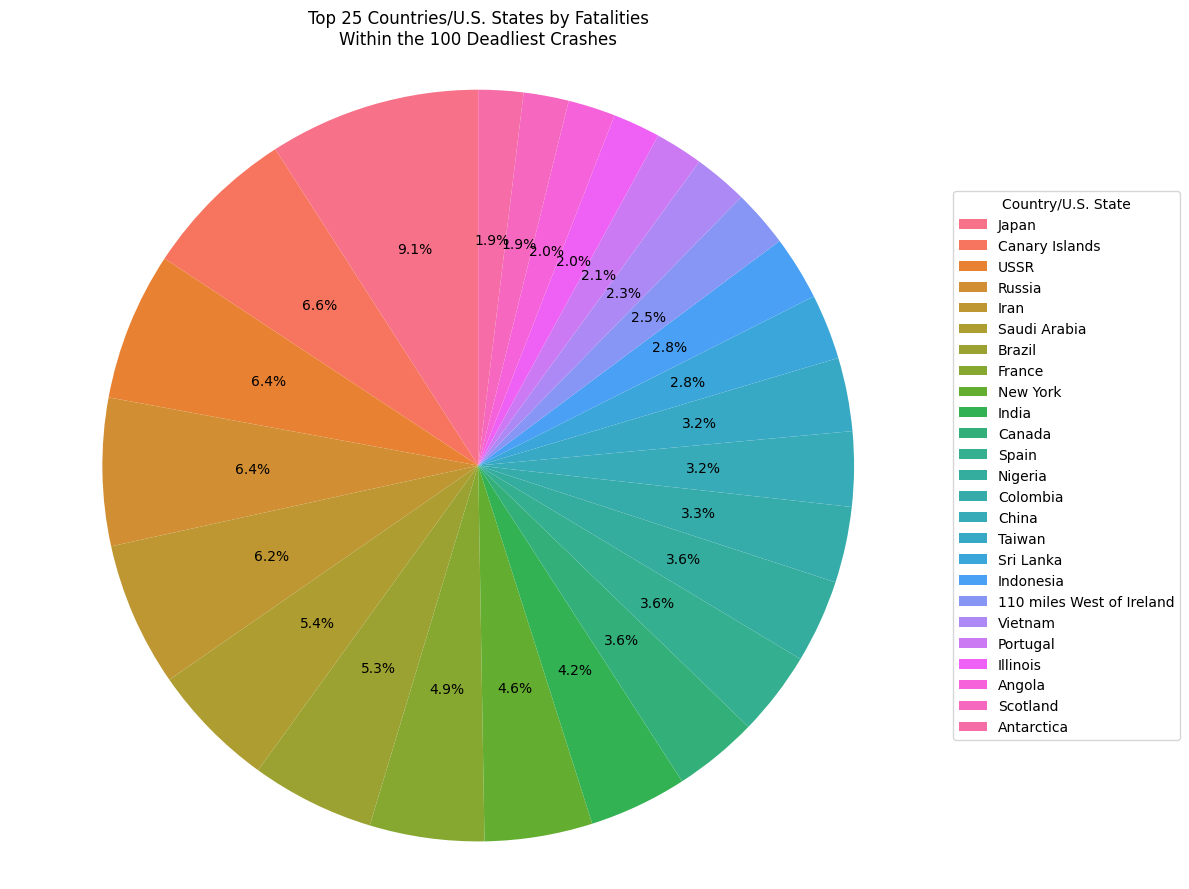

In [23]:
# Add fatalities for each country or U.S. state
fatalities_by_place = top_100_fatalities.groupby(
    "State/Country"
)["Fatalities"].sum()

# Select the top 25
top_25_places = fatalities_by_place.sort_values(
    ascending=False
).head(25)

display(top_25_places)

# Create the pie chart
colors = sns.color_palette("husl", len(top_25_places))

plt.figure(figsize=(12, 9))
plt.pie(
    top_25_places.values,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors
)

plt.legend(
    top_25_places.index,
    title="Country/U.S. State",
    bbox_to_anchor=(1, 0.5),
    loc="center left"
)

plt.title(
    "Top 25 Countries/U.S. States by Fatalities\n"
    "Within the 100 Deadliest Crashes"
)
plt.axis("equal")
plt.tight_layout()
plt.show()

## Groupwork Evidence

The photo below shows Audrey Ayieko, Joy Karanja and Felicia Agwata working on the assignment.

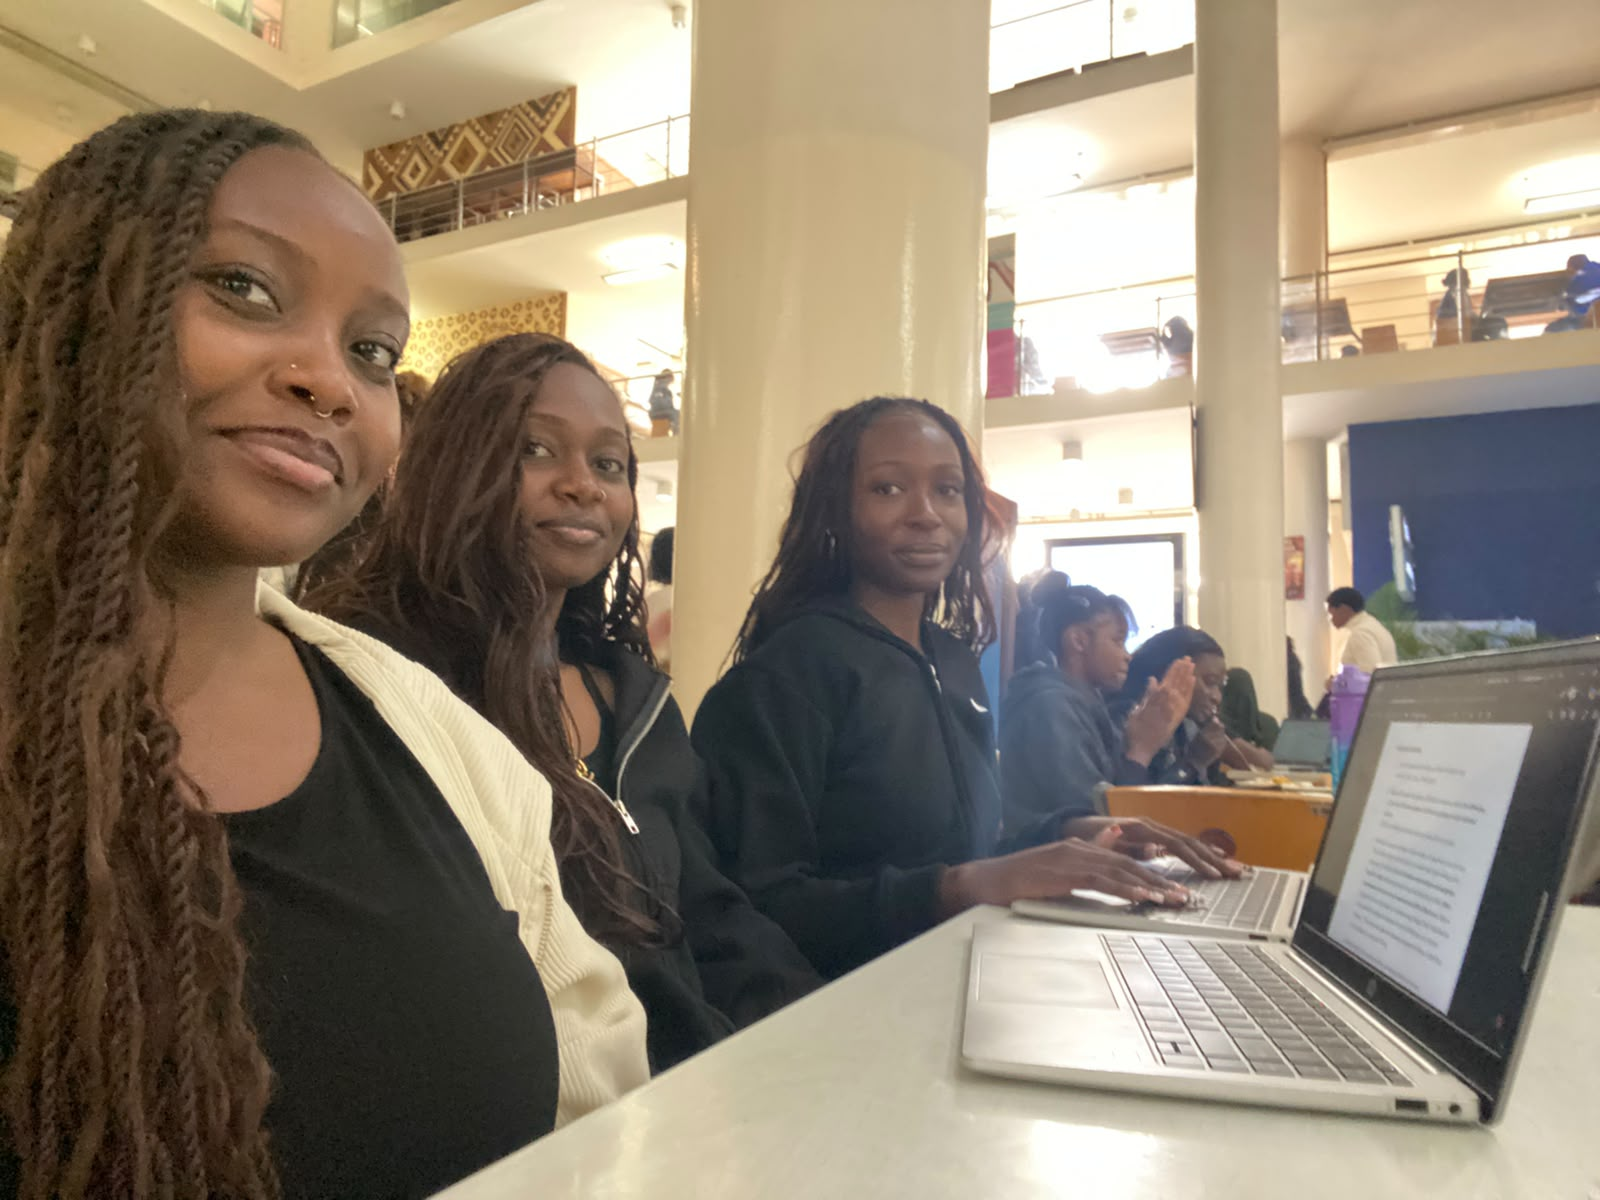